# Identification on the lidar paths

Step 12.1. The Phase 5 model (`system_identification.ipynb`) was fitted on 1 s segments of an overhead
video. Replayed over a whole handbrake run it misses the stop by 30-50 cm. Here the ground truth is the
lidar: `scripts/lidar_path.py` lays every scan, each beam moved to where the car was when it was taken, on
the scans at rest before the run, and gives the path of the rear axle at 6.8 Hz. With it: the time bases of
the sensors, a refit of the car in grip, in the braked slide and in the drift, and the rear wheel speed
against its command.

Runs: grip turns and full-lock turns with a braked slide (`hbg`, `hbl`, `hbf`, `hbb`, `hbp`,
`handbrake.ipynb`, `parking.ipynb`), a donut and five drift runs (`donut_check`, `drift_car4-9`,
`drift.ipynb`), eight kicks into a drift and a braked slide (`hbk_1-8`, `sideways.ipynb`) and three gap
parkings (`gap_1-3`). Paths: `lidar_path.py <run> <from> <to>`, from the first wheel motion to 1 s after
the last.

In [1]:
import sys
sys.path.append('../scripts')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import vehicle_model as vm

plt.rcParams['figure.dpi'] = 72
B = '../data/bags'
H = 0.002                  # s, model step
LAG_ENC = 0.007            # s, encoder count read to /joint_states received (6.1)
GRIP = ['hbg_1', 'hbg_2', 'hbg_3', 'hbl_1', 'hbl_2', 'hbl_3', 'hbl_4', 'hbl_6', 'hbl_7', 'hbl_8', 'hbl_9',
        'hbf_1', 'hbf_2', 'hbf_3', 'hbf_4', 'hbf_5']
LOCK = ['hbb_1', 'hbb_2', 'hbb_3', 'hbb_4', 'hbb_5', 'hbp_1', 'hbp_2', 'hbp_3']
DRIFT = ['donut_check', 'drift_car4', 'drift_car5', 'drift_car6', 'drift_car7', 'drift_car9']
KICK = [f'hbk_{i}' for i in range(1, 9)] + ['gap_1', 'gap_2', 'gap_3']


def read(run, name):
    return pd.read_parquet(f'{B}/{run}_parquet/{name}.parquet')


def encoder(run):
    # rear wheel distance and surface speed from the encoder count, on the time it was read (the speed in
    # /joint_states has the firmware's 45 ms EMA)
    j = read(run, 'joint_states')
    t = j['t'].to_numpy() - LAG_ENC
    pos = (j['pl'] + j['pr']).to_numpy() / 2 * vm.p['wheel_radius']
    return t, pos, np.interp(t, t[1:-1], (pos[2:] - pos[:-2]) / (t[2:] - t[:-2]))

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## The lidar path

Each scan laid on the scans at rest: point-to-point ICP after moving every beam by the gyro heading and the
position between scans (the car turns up to 30 deg and moves up to 15 cm in one 147 ms turn of the A1).
Per scan: the rms distance of the kept point pairs and the share of points kept.

In [2]:
rows = []
for run in GRIP + LOCK + DRIFT + KICK:
    o = read(run, 'lidar_path')
    rows.append({'run': run, 'group': run.rstrip('0123456789_').replace('drift_car', 'drift'), 'scans': len(o),
                 'rms [cm]': 100 * o['rms'].median(), 'rms max [cm]': 100 * o['rms'].max(),
                 'share min': o['share'].min(), 'heading correction rms [deg]': np.degrees(np.sqrt(np.mean(o['dyaw'] ** 2)))})
paths = pd.DataFrame(rows)
paths.groupby('group').agg(runs=('run', 'size'), scans=('scans', 'sum'), rms=('rms [cm]', 'median'),
                           rms_max=('rms max [cm]', 'max'), share_min=('share min', 'min'),
                           heading=('heading correction rms [deg]', 'median')).round(2)

,runs,scans,rms,rms_max,share_min,heading
group,,,,,,
donut_check,1,66,1.08,1.59,0.80,2.41
drift,5,278,1.08,1.39,0.80,0.99
gap,3,82,0.87,2.22,0.55,0.60
hbb,5,178,1.25,1.99,0.44,0.45
hbf,5,189,1.25,1.58,0.48,0.37
hbg,3,104,0.97,1.27,0.83,0.32
hbk,8,222,0.94,1.34,0.63,0.42
hbl,8,288,1.00,1.37,0.84,0.34
hbp,3,106,1.18,1.70,0.60,0.34


The end of the path against the stop measured by ICP of the last scans on the first ones (`parking.ipynb`):

In [3]:
ICP = {'hbl_1': (1.519, 0.958), 'hbl_2': (1.503, 0.939), 'hbl_3': (1.558, 0.935), 'hbl_4': (1.500, 1.018),
       'hbl_6': (1.500, 1.057), 'hbl_7': (1.468, 0.954), 'hbl_8': (1.569, 1.150), 'hbl_9': (1.519, 1.131),
       'hbf_1': (1.763, 0.993), 'hbf_2': (1.796, 1.089), 'hbf_3': (1.784, 1.050), 'hbf_4': (1.793, 1.037),
       'hbf_5': (1.752, 1.043)}
d = np.array([[read(r, 'lidar_path')[c].iloc[-1] - ICP[r][i] for i, c in enumerate('xy')] for r in ICP])
print(f'path end - ICP stop: x {100 * d[:, 0].mean():+.1f} +- {100 * d[:, 0].std():.1f} cm, '
      f'y {100 * d[:, 1].mean():+.1f} +- {100 * d[:, 1].std():.1f} cm ({len(d)} runs)')

path end - ICP stop: x -0.0 +- 0.2 cm, y +0.4 +- 0.4 cm (13 runs)


### Result

Per scan 0.9-1.3 cm rms (median by group), 2.2 at most; what ICP still turns a scan by is 0.3-1.0 deg rms
(2.4 in the donut, 3.9 rad/s). The end of the path is the ICP stop within 0.4 cm.

## Time bases

The model is driven by the commands and the wheel speed and compared with the lidar and the gyro, so each
needs its time. The reference is the encoder count: read when /joint_states is published, received 7 ms
later (6.1). The commands reach the ESP32 30 ms after /drive is sent (its echo on /steering_angle 32 ms).

**Lidar.** On the launch the car goes straight: the lidar x against the encoder distance, x = k d(t - lag)
+ c, the lag on a grid. Scan time here: receive time less half a turn (rplidar_ros stamps its call for
the scan, which slips against the rotation by 13 ms at times).

In [4]:
def launch_lag(run, x_max):
    t, pos, u = encoder(run)
    o = read(run, 'lidar_path')
    t0 = t[np.argmax(u > 0.05)]
    sel = (o['t'] > t0 - 0.5) & (o['x'] < x_max)
    ts, xs = o.loc[sel, 't'].to_numpy(), o.loc[sel, 'x'].to_numpy()
    best = None
    for lag in np.arange(0.0, 0.15, 0.001):
        A = np.c_[np.interp(ts - lag, t, pos), np.ones(len(ts))]
        sol, *_ = np.linalg.lstsq(A, xs, rcond=None)
        e = np.sqrt(np.mean((A @ sol - xs) ** 2))
        if best is None or e < best[0]:
            best = (e, lag, sol[0])
    return best


rows = []
for run in GRIP[1:] + LOCK + KICK:        # hbg_1 is already moving when its scans start
    e, lag, k = launch_lag(run, 0.35 if run in KICK else 0.8)
    rows.append({'run': run, 'session': 'kick' if run in KICK else 'handbrake', 'lag [ms]': 1000 * lag, 'k': k,
                 'rms [cm]': 100 * e})
lags = pd.DataFrame(rows)
lags.groupby('session')[['lag [ms]', 'k', 'rms [cm]']].agg(['mean', 'std', 'min', 'max']).round(3)

lag [ms]                          k                      rms [cm]  \
              mean     std   min   max   mean    std    min    max     mean   
session                                                                       
handbrake   76.261  10.441  55.0  94.0  0.981  0.012  0.958  1.002    0.417   
kick        55.364   5.921  45.0  65.0  1.048  0.012  1.024  1.069    0.187   

                                
             std    min    max  
session                         
handbrake  0.133  0.231  0.708  
kick       0.045  0.091  0.247

**Gyro.** The paths are built with the gyro heading (raw /imu/data_raw, read `GYRO_EARLY` = 12 ms before
the lidar time, x `GYRO_SCALE` = 1.0054). What ICP still turns each scan by, against the yaw rate and the
heading: a gyro still early or late by delta turns the scan by r delta, a scale off by e by psi e.

In [5]:
rows = []
for run in GRIP + LOCK + KICK:
    o, g = read(run, 'lidar_path'), read(run, 'gyro_path')
    rows.append(pd.DataFrame({'run': run, 'r': np.interp(o['t'], g['t'], g['r']), 'psi': np.interp(o['t'], g['t'], g['psi']),
                              'dyaw': o['dyaw']}))
df = pd.concat(rows)
A = np.c_[df['r'], df['psi'], pd.get_dummies(df['run']).to_numpy(float)]
sol, *_ = np.linalg.lstsq(A, df['dyaw'], rcond=None)
print(f'left over: {1000 * sol[0]:+.1f} ms, scale {sol[1]:+.4f}; residual {np.degrees(np.std(df["dyaw"] - A @ sol)):.2f} deg, '
      f'{len(df)} scans, |r| up to {df["r"].abs().max():.1f} rad/s')

left over: +0.4 ms, scale +0.0001; residual 0.37 deg, 1169 scans, |r| up to 3.9 rad/s


A node reads the gyro at its 50 Hz tick, when the last message may be up to 20 ms old: the handbrake node's
state (latest gyro at the tick) against the raw message:

In [6]:
out = []
for run in GRIP:
    s, im = read(run, 'handbrake_state'), read(run, 'imu_data_raw')
    t = np.arange(s['t'].iloc[0] + 1, s['t'].iloc[-1] - 1, 0.001)
    a = np.interp(t, s['t'], s['r'])
    ds = np.arange(-0.02, 0.04, 0.001)
    e = [np.mean((a - np.interp(t - d, im['t'], im['gz'] - im['gz'].iloc[:40].median())) ** 2) for d in ds]
    out.append(ds[int(np.argmin(e))])
print(f'node state after the raw message: {1000 * np.mean(out):.1f} +- {1000 * np.std(out):.1f} ms ({len(out)} runs)')

node state after the raw message: 11.7 +- 3.0 ms (16 runs)


### Result

- Lidar: the scan was taken 76 +- 10 ms before its receive time less half a turn in the handbrake sessions,
  55 +- 6 ms in the kick sessions (car over encoder distance, k: 0.98 at full throttle, 1.05 at 0.4 m/s). It moves
  with the driver's grab from session to session.
- Gyro: 12 ms ahead of the lidar and 0.54% low; what ICP leaves over is 0.4 ms and 0.01%. The IMU message is
  then 43-64 ms late (the two sessions), and a node reading it at its tick sees it 11.7 +- 3.0 ms older.
- So `handbrake.py` braked 13-15 deg later than its gyro said at 3.5 rad/s (`sideways.ipynb`), and the handbrake
  node's box corner was ~8 cm off at 1.1 m/s: absorbed so far by `END_BIAS` and `turn_at`.

## The model against the car

Everything on the time the car did it: the commands DEAD after /drive, the wheel speed from the encoder,
the gyro and lidar paths less the lidar lag of their session (the drift runs have no straight launch: the
handbrake sessions' lag). The model, 2 ms Euler: the steering command through the servo (rate limit
`steer_rate_max`, then a lag), the measured wheel speed, the tires; rear axle path, heading, yaw rate.

Two ways to compare: windows of 1.2 s started from the measured state every third scan (position and
velocity from a quadratic through five scans, yaw rate from the gyro), and the kick runs whole, from the
kick to 1 s after the brake.

In [7]:
LAG = {'handbrake': lags.loc[lags['session'] == 'handbrake', 'lag [ms]'].mean() / 1000,
       'kick': lags.loc[lags['session'] == 'kick', 'lag [ms]'].mean() / 1000}
DEAD = vm.STEER_DEAD
WIN, EVERY, PRE = 1.2, 3, 0.3    # s window, scans between window starts, s of steering before a start


def rot(a):
    return np.array([[np.cos(a), np.sin(a)], [-np.sin(a), np.cos(a)]])


def signals(run):
    d = read(run, 'drive')
    t_enc, pos, u = encoder(run)
    lag = LAG['kick'] if run in KICK else LAG['handbrake']
    o = read(run, 'lidar_path').assign(t=lambda x: x['t'] - lag)
    g = read(run, 'gyro_path').assign(t=lambda x: x['t'] - lag)
    ts = np.arange(g['t'].iloc[0], g['t'].iloc[-1], H)
    return dict(ts=ts, u=np.interp(ts, t_enc, u), steer=np.interp(ts - DEAD, d['t'], d['cmd_steer']),
                braked=np.interp(ts - DEAD, d['t'], d['cmd_speed']) < 0.02, r=np.interp(ts, g['t'], g['r']),
                psi=np.interp(ts, g['t'], g['psi']), o=o, drive=d)


def start(S, run, t0, v, n):
    # a comparison from t0: velocity v (world, rear axle), n steps
    k0 = int(round((t0 - S['ts'][0]) / H))
    npre = int(PRE / H)
    o = S['o']
    ti = o['t'].to_numpy()
    inside = (ti > t0) & (ti < t0 + n * H)
    vb = rot(S['psi'][k0]) @ v
    return dict(run=run, n=n, u=S['u'][k0:k0 + n], steer=S['steer'][k0 - npre:k0 + n], braked=S['braked'][k0:k0 + n],
                r=S['r'][k0:k0 + n], psi=S['psi'][k0:k0 + n], x0=np.interp(t0, ti, o['x']), y0=np.interp(t0, ti, o['y']),
                psi0=S['psi'][k0],
                vx=vb[0], vy_rear=vb[1], r0=S['r'][k0], scan_k=np.round((ti[inside] - t0) / H).astype(int),
                scan_xy=o[['x', 'y']].to_numpy()[inside])


def windows(run):
    S = signals(run)
    o = S['o']
    ti, xy = o['t'].to_numpy(), o[['x', 'y']].to_numpy()
    out = []
    for i in range(2, len(o) - 2, EVERY):
        if ti[i] - PRE < S['ts'][0] or ti[i] + WIN > S['ts'][-1]:
            continue
        c = np.polyfit(ti[i - 2:i + 3] - ti[i], xy[i - 2:i + 3], 2)
        if np.hypot(*c[1]) > 0.15:
            out.append(start(S, run, ti[i], c[1], int(WIN / H)))
    return out


def kick_whole(run):
    S = signals(run)
    d, o = S['drive'], S['o']
    t_kick = d.loc[d['cmd_speed'] > 1.0, 't'].iloc[0]
    t_brake = d.loc[(d['t'] > t_kick) & (d['cmd_speed'] < 0.02), 't'].iloc[0]
    pre = o[o['t'] < t_kick].iloc[-5:]
    v = np.polyfit(pre['t'] - t_kick, pre[['x', 'y']].to_numpy(), 1)[0]
    w = start(S, run, t_kick, v, int((t_brake + DEAD + 1.0 - t_kick) / H))
    w['k_brake'] = int((t_brake + DEAD - t_kick) / H)
    return w


def simulate(W, q):
    # the comparisons at once, padded to the longest: rear axle x, y, heading, yaw rate per step
    n = max(w['n'] for w in W)
    pad = lambda k, m: np.stack([np.pad(w[k], (0, m - len(w[k])), mode='edge') for w in W])
    npre = int(PRE / H)
    u, braked, dmap = pad('u', n), pad('braked', n), np.interp(pad('steer', n + npre), vm.CMD, vm.DEL)
    st = lambda k: np.array([w[k] for w in W], dtype=float)
    servo = d = dmap[:, 0]
    for i in range(npre):
        servo = servo + np.clip(dmap[:, i] - servo, -vm.STEER_RATE * H, vm.STEER_RATE * H)
        d = d + H * (servo - d) / q['tau']
    psi, r, vx = st('psi0'), st('r0'), st('vx')
    vy = st('vy_rear') + vm.LR * r
    X, Y = st('x0') + vm.LR * np.cos(psi), st('y0') + vm.LR * np.sin(psi)
    ax = ay = np.zeros(len(W))
    go = np.ones(len(W), bool)
    out = np.zeros((4, len(W), n))
    for i in range(n):
        out[:, :, i] = X - vm.LR * np.cos(psi), Y - vm.LR * np.sin(psi), psi, r
        fx, fy, mz = vm.forces_fit(vx, vy, r, d, u[:, i], braked[:, i], ax, ay, q)
        ax, ay = fx / vm.M, fy / vm.M
        c, s = np.cos(psi), np.sin(psi)
        X, Y, psi = X + go * H * (vx * c - vy * s), Y + go * H * (vx * s + vy * c), psi + go * H * r
        vx, vy, r = (np.maximum(vx + go * H * (ax + vy * r), 0.0), vy + go * H * (ay - vx * r), r + go * H * mz / vm.IZ)
        servo = servo + np.clip(dmap[:, npre + i] - servo, -vm.STEER_RATE * H, vm.STEER_RATE * H)
        d = d + H * (servo - d) / q['tau']
        go &= ~(braked[:, i] & (np.hypot(vx, vy + vm.LF * r) < 0.04) & (np.hypot(vx, vy - vm.LR * r) < 0.04))
        vx, vy, r = vx * go, vy * go, r * go
    return out


def residuals(W, q, sig_p=0.02, sig_r=0.15):
    out = simulate(W, q)
    res = []
    for k, w in enumerate(W):
        res += [(out[0, k, w['scan_k']] - w['scan_xy'][:, 0]) / sig_p, (out[1, k, w['scan_k']] - w['scan_xy'][:, 1]) / sig_p,
                (out[3, k, :w['n']:10] - w['r'][::10]) / sig_r]
    return np.concatenate(res)


def report(W, q):
    out = simulate(W, q)
    rows = []
    for k, w in enumerate(W):
        e = np.hypot(out[0, k, w['scan_k']] - w['scan_xy'][:, 0], out[1, k, w['scan_k']] - w['scan_xy'][:, 1])
        rows.append({'group': w['run'].rstrip('0123456789_').replace('drift_car', 'drift'), 'end [cm]': 100 * e[-1],
                     'r rms': np.sqrt(np.mean((out[3, k, :w['n']] - w['r']) ** 2))})
    return pd.DataFrame(rows).groupby('group').agg(windows=('end [cm]', 'size'), end_median=('end [cm]', 'median'),
                                                    end_p90=('end [cm]', lambda x: x.quantile(0.9)), r_rms=('r rms', 'median'))


W = [w for run in GRIP + LOCK + DRIFT + KICK for w in windows(run)]
K = [kick_whole(run) for run in KICK]
print(len(W), 'windows,', len(K), 'kick runs whole')

358 windows, 11 kick runs whole


### The Phase 5 model

The Phase 5 tires with the rear x 1.5 while braked (`handbrake.ipynb`), the steering through its first-order
lag of 0.169 s (no dead time, no rate limit), load transfer none, lambda 1:

In [8]:
PHASE5 = dict(mu_f=vm.MU_F, b_f=vm.B_F, mu_r=vm.MU_R, b_r=vm.B_R, lam=1.0, locked=1.5, locked_y=1.5, lt_x=0.0,
              lt_y=0.0, tau=vm.TAU)
report(W[1::2], PHASE5).round(2)

,windows,end_median,end_p90,r_rms
group,,,,
donut_check,9,8.55,11.76,0.39
drift,38,6.74,27.02,0.51
gap,8,5.70,9.84,0.38
hbb,22,6.68,17.45,0.28
hbf,23,6.20,18.58,0.33
hbg,12,5.34,15.96,0.32
hbk,20,6.52,10.76,0.45
hbl,34,6.47,16.05,0.29
hbp,13,6.38,24.17,0.34


In [9]:
def kick_report(ks, q):
    out = simulate(ks, q)
    rows = []
    for k, w in enumerate(ks):
        kb, m = w['k_brake'], w['n'] - 1
        rows.append({'run': w['run'], 'heading at the brake [deg]': np.degrees(out[2, k, kb] - w['psi'][kb]),
                     'heading at the stop [deg]': np.degrees(out[2, k, m] - w['psi'][m]),
                     'stop [cm]': 100 * np.hypot(out[0, k, w['scan_k'][-1]] - w['scan_xy'][-1, 0], out[1, k, w['scan_k'][-1]] - w['scan_xy'][-1, 1])})
    return pd.DataFrame(rows).set_index('run')


kick_report(K, PHASE5).round(1).T

run,hbk_1,hbk_2,hbk_3,hbk_4,hbk_5,hbk_6,hbk_7,hbk_8,gap_1,gap_2,gap_3
heading at the brake [deg],-11.2,-21.4,-20.2,-13.6,-22.4,-19.7,-23.2,-16.9,-13.2,-12.3,-22.0
heading at the stop [deg],-11.9,-19.8,-18.1,-8.3,-17.9,-19.1,-18.9,-13.9,-9.2,-12.0,-18.1
stop [cm],6.0,9.2,10.1,8.0,9.6,8.3,10.0,7.6,9.0,7.6,9.8


### The refit

The same tire formulas and C, plus what the runs ask for: longitudinal and lateral load transfer from the
last step's acceleration (`lt_x` of m a_x h / L, `lt_y` of m a_y h / T, all on the rear axle), the
longitudinal slip of the rear weighed down by lambda, and while braked the rear friction x `locked` along
the wheel and x `locked_y` across it (a straight brake slides at 0.41, `handbrake.ipynb`; nothing says
sideways is the same). Fitted on every other window and every other kick run, least squares on the lidar
positions (2 cm) and the gyro yaw rate (0.15 rad/s); the other half held out.

In [10]:
FREE = ['mu_f', 'b_f', 'mu_r', 'b_r', 'lam', 'locked', 'locked_y', 'lt_x', 'lt_y', 'tau']
LO = dict(mu_f=0.1, b_f=1.0, mu_r=0.1, b_r=1.0, lam=0.3, locked=0.5, locked_y=0.5, lt_x=0.0, lt_y=0.0, tau=0.02)
HI = dict(mu_f=1.0, b_f=150.0, mu_r=1.0, b_r=150.0, lam=5.0, locked=3.0, locked_y=3.0, lt_x=2.0, lt_y=2.5, tau=0.5)
p0 = np.array([PHASE5[k] for k in FREE])
p0[FREE.index('lt_x')] = p0[FREE.index('lt_y')] = 1.0
fit = least_squares(lambda p: np.concatenate([residuals(W[::2], dict(zip(FREE, p))), residuals(K[::2], dict(zip(FREE, p)))]),
                    p0, bounds=([LO[k] for k in FREE], [HI[k] for k in FREE]), x_scale=np.abs(p0) * 0.3 + 0.01,
                    diff_step=1e-3, max_nfev=300)
REFIT = dict(zip(FREE, fit.x))
pd.Series(REFIT).round(3)

mu_f         0.313
b_f         48.383
mu_r         0.297
b_r         18.906
lam          1.372
locked       1.356
locked_y     0.912
lt_x         0.009
lt_y         1.371
tau          0.035
dtype: float64

In [11]:
report(W[1::2], REFIT).round(2)

,windows,end_median,end_p90,r_rms
group,,,,
donut_check,9,5.60,7.83,0.17
drift,38,3.94,14.18,0.29
gap,8,4.10,6.12,0.16
hbb,22,5.45,8.88,0.18
hbf,23,4.22,6.75,0.15
hbg,12,4.17,8.56,0.14
hbk,20,3.54,7.25,0.20
hbl,34,4.88,8.05,0.15
hbp,13,3.40,12.43,0.22


In [12]:
kick_report(K, REFIT).round(1).T

run,hbk_1,hbk_2,hbk_3,hbk_4,hbk_5,hbk_6,hbk_7,hbk_8,gap_1,gap_2,gap_3
heading at the brake [deg],3.0,-6.7,-5.8,-0.3,-7.6,-5.3,-9.2,-3.0,-0.4,0.4,-6.4
heading at the stop [deg],1.3,-7.5,-5.4,2.4,-6.1,-6.4,-7.7,-1.0,2.6,0.1,-2.8
stop [cm],4.7,3.6,5.1,10.4,4.7,4.6,9.0,6.9,7.8,6.4,7.2


### Result

Held out: the end of the 1.2 s windows 3.4-5.6 cm off (median by group; 5.3-8.6 with the Phase 5 model on
the same time bases), p90 6-14 cm (11-27), the yaw rate 0.14-0.29 rad/s rms (0.28-0.51). The kick runs whole:
the heading at the brake -9..+3 deg (-11..-23), the stop 4-10 cm off.

The fit asks for the lateral load transfer 1.37 times the rigid car's (the body rolls), none longitudinally,
and a locked rear 1.36 along the wheel but 0.91 across it: braking straight the rear slides with 0.40, sideways
with 0.27. The steering lag after the servo's rate limit is 35 ms (0.169 s in Phase 5, without dead time and
rate limit).

The slide after a drift brake, from the car's state 0.25 s before it: +1.1 +- 2.7 deg over 11 runs (the car
23-38 deg, full lock the most).

### The slide after a drift brake

What the gap node predicts every step: the slide to the stop. From 0.25 s before the brake (in the drift the
velocity from the scans is clean; around the brake the car slows within one scan) with what was sent, the
heading at the brake set to the real one, the rotation from the brake to the stop:

In [13]:
def slides(q):
    rows = []
    for run in KICK:
        S = signals(run)
        d, o = S['drive'], S['o']
        t_kick = d.loc[d['cmd_speed'] > 1.0, 't'].iloc[0]
        t_brake = d.loc[(d['t'] > t_kick) & (d['cmd_speed'] < 0.02), 't'].iloc[0] + DEAD
        t0 = t_brake - 0.25
        i = np.searchsorted(o['t'], t0)
        w5 = o.iloc[i - 2:i + 3]
        v = np.polyfit(w5['t'] - t0, w5[['x', 'y']].to_numpy(), 2)[1]
        w = start(S, run, t0, v, int(1.45 / H))
        out = simulate([w], q)
        kb = int(0.25 / H)
        psi_b = np.interp(t_brake, S['ts'], S['psi'])
        real = S['psi'][-1] - psi_b
        model = out[2, 0, -1] - out[2, 0, kb]
        rows.append({'run': run, 'steering': S['steer'][int((t_brake - S['ts'][0]) / H):][:200].mean(),
                     'real [deg]': np.degrees(real), 'model [deg]': np.degrees(model)})
    return pd.DataFrame(rows).set_index('run')


sl = slides(REFIT)
print(f'model - real: {(sl["model [deg]"] - sl["real [deg]"]).mean():+.1f} +- {(sl["model [deg]"] - sl["real [deg]"]).std():.1f} deg')
sl.round(2).T

model - real: +1.1 +- 2.7 deg


run,hbk_1,hbk_2,hbk_3,hbk_4,hbk_5,hbk_6,hbk_7,hbk_8,gap_1,gap_2,gap_3
steering,0.52,0.52,0.00,0.00,0.52,0.52,0.52,0.52,-0.15,-0.10,0.48
real [deg],38.40,36.68,26.46,22.65,32.63,37.01,33.07,35.03,25.99,30.95,33.76
model [deg],36.60,36.13,26.08,26.32,35.49,36.20,34.88,38.51,29.22,27.37,38.48


### Two runs whole

The donut (`drift.ipynb`: full lock at 0.6 m/s, then full throttle) and `drift_car4`, where the Phase 5 model
spun and the car stayed in grip, from rest with the measured wheel speed:

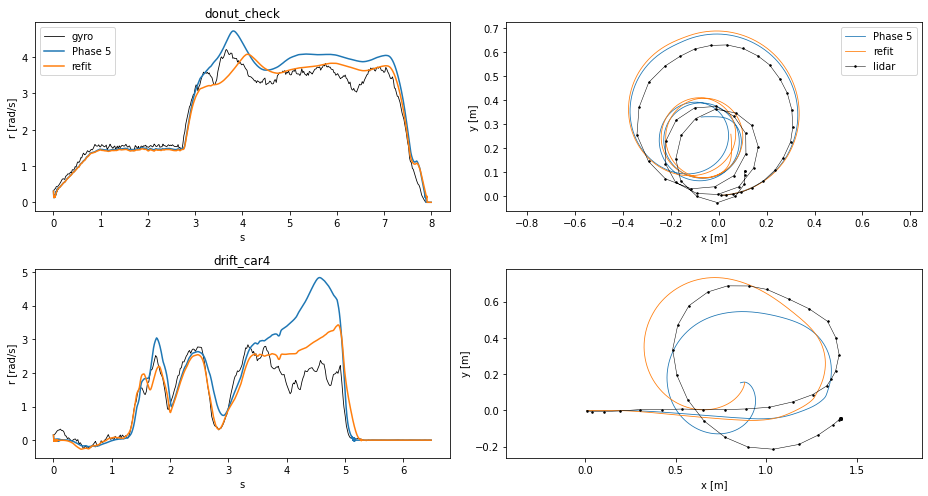

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for row, run in enumerate(['donut_check', 'drift_car4']):
    S = signals(run)
    t_enc, pos, u = encoder(run)
    t0 = t_enc[np.argmax(u > 0.05)] + 0.05
    w = start(S, run, t0, np.zeros(2), int(min(8.0, S['ts'][-1] - t0 - 0.1) / H))
    tt = np.arange(w['n']) * H
    ax[row, 0].plot(tt, w['r'], 'k', lw=0.8, label='gyro')
    for q, name, c in [(PHASE5, 'Phase 5', 'C0'), (REFIT, 'refit', 'C1')]:
        out = simulate([w], q)
        ax[row, 0].plot(tt, out[3, 0], c, label=name)
        ax[row, 1].plot(out[0, 0], out[1, 0], c, lw=0.8, label=name)
    ax[row, 1].plot(w['scan_xy'][:, 0], w['scan_xy'][:, 1], 'k.-', ms=3, lw=0.5, label='lidar')
    ax[row, 0].set(title=run, xlabel='s', ylabel='r [rad/s]')
    ax[row, 1].set(xlabel='x [m]', ylabel='y [m]')
    ax[row, 1].axis('equal')
ax[0, 0].legend()
ax[0, 1].legend()
plt.tight_layout()
plt.show()

The donut: the refit follows the gyro, 3.6-3.8 rad/s against 3.4-3.7 (Phase 5 up to 4.7). `drift_car4`: the
refit still breaks loose at 4.2 s, to 3.4 rad/s where the car stayed in grip at 2.0-2.5; later and less than
Phase 5 (4.8). Where the car goes from grip to drift at full lock stays the hardest thing to predict.

## The wheel speed

For planning, the rear wheel speed from its command: the speed loop K within the motor line, u' <= A (1 -
u/U), and u' >= -D; a command under 0.02 m/s leaves the motor shorted, u' = -u / tau_b. Command DEAD late
as the steering. All runs above:

In [15]:
def wheel_run(p, ts, cmd, u0):
    K, A, U, D, TB = p
    u = np.zeros(len(ts))
    u[0] = u0
    for i in range(1, len(ts)):
        c = cmd[i - 1]
        du = -u[i - 1] / TB if c < 0.02 else np.clip(K * (min(c, U) - u[i - 1]), -D, A * (1 - u[i - 1] / U))
        u[i] = max(u[i - 1] + H * du, 0.0)
    return u


WHEELS = []
for run in GRIP + LOCK + DRIFT + KICK:
    d = read(run, 'drive')
    t_enc, pos, u = encoder(run)
    ts = np.arange(d['t'].iloc[0], min(d['t'].iloc[-1] + 1.0, t_enc[-1]), H)
    WHEELS.append((ts, np.interp(ts, t_enc, u), np.interp(ts - DEAD, d['t'], d['cmd_speed'], left=0.0)))
wfit = least_squares(lambda p: np.concatenate([(wheel_run(p, ts, c, u[0]) - u)[::5] for ts, u, c in WHEELS]),
                     [8.0, 10.0, 1.2, 3.0, 0.07], bounds=([0.5, 1, 0.9, 0.3, 0.02], [50, 40, 1.5, 20, 0.3]))
print('K %.2f 1/s, A %.2f m/s2, U %.3f m/s, D %.2f m/s2, tau_b %.3f s' % tuple(wfit.x),
      f'; rms {np.sqrt(np.mean(wfit.fun ** 2)):.3f} m/s')

K 12.49 1/s, A 10.79 m/s2, U 1.163 m/s, D 6.86 m/s2, tau_b 0.084 s ; rms 0.021 m/s


0.021 m/s rms over the 41 runs. From 0.4 m/s the kick starts at 10.8 (1 - 0.4 / 1.163) = 7.1 m/s2 at the
wheel.